## Задача 1

Реализовать класс для работы с линейной регрессией

Используя датасет про автомобили (целевой признак — price), сравнить (качество, скорость обучения и предсказания, важность признаков) модели `MyLinearRegression` с различными гиперпараметрами, сделать выводы. На этом же датасете сравнить модель `MyLinearRegression` с библиотечной реализацией из `sklearn`, составить таблицу(ы) (графики) результатов сравнения (качество, скорость обучения и предсказания, важность признаков).

In [1]:
import numpy as np
import pandas as pd

class MyLinearRegression:
    def __init__(self,
                 regularization=None,
                 weight_calc='matrix',
                 lambda_1=None,
                 lambda_2=None,
                 batch_size=20,
                 alpha=0.01,
                 max_iter=5000,
                 early_stopping=1e-4,
                 random_state=42):

        if regularization not in [None, 'l1', 'l2', 'l1l2']:
            raise TypeError(f"regularization must be one of None, 'l1','l2','l1l2', got {regularization}")
        if weight_calc not in ['matrix', 'gd', 'sgd']:
            raise TypeError(f"weight_calc must be 'matrix','gd','sgd', got {weight_calc}")
        if regularization in ['l1', 'l1l2'] and lambda_1 is None:
            raise TypeError("lambda_1 is required for 'l1' or 'l1l2'")
        if regularization in ['l2', 'l1l2'] and lambda_2 is None:
            raise TypeError("lambda_2 is required for 'l2' or 'l1l2'")
        if weight_calc == 'matrix' and regularization in ['l1', 'l1l2']:
            raise TypeError("For 'l1'/'l1l2' нельзя использовать 'matrix' (нет аналитического решения)")

        self.regularization = regularization
        self.weight_calc = weight_calc
        self.lambda_1 = lambda_1
        self.lambda_2 = lambda_2
        self.batch_size = batch_size
        self.alpha = alpha
        self.max_iter = max_iter
        self.early_stopping = early_stopping
        self.random_state = random_state

        self.coefs_ = None
        self.intercept_ = None
        self.n_iter_ = 0

    def _to_numpy(self, X, y=None):
        if isinstance(X, (pd.DataFrame, pd.Series)):
            X = X.to_numpy()
        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        if y is None:
            return X

        if isinstance(y, (pd.DataFrame, pd.Series)):
            y = y.to_numpy()
        y = np.asarray(y).reshape(-1)
        return X, y

    def _add_intercept(self, X):
        return np.c_[np.ones(X.shape[0]), X]

    def _grad(self, Xb, y, w):
        n = Xb.shape[0]
        pred = Xb @ w
        grad = (2.0 / n) * (Xb.T @ (pred - y))

        if self.regularization == 'l1':
            grad[1:] += self.lambda_1 * np.sign(w[1:])
        elif self.regularization == 'l2':
            grad[1:] += 2.0 * self.lambda_2 * w[1:]
        elif self.regularization == 'l1l2':
            grad[1:] += self.lambda_1 * np.sign(w[1:]) + 2.0 * self.lambda_2 * w[1:]
        return grad

    def _fit_matrix(self, Xb, y):
        XtX = Xb.T @ Xb
        Xty = Xb.T @ y

        if self.regularization is None:
            w = np.linalg.pinv(XtX) @ Xty
        elif self.regularization == 'l2':
            p = XtX.shape[0]
            I = np.eye(p)
            I[0, 0] = 0.0
            w = np.linalg.pinv(XtX + self.lambda_2 * I) @ Xty
        else:
            raise RuntimeError("matrix поддерживает только None или 'l2'")
        return w

    def _fit_gd(self, Xb, y):
        rng = np.random.default_rng(self.random_state)
        w = rng.normal(scale=0.01, size=Xb.shape[1])

        for it in range(self.max_iter):
            grad = self._grad(Xb, y, w)
            w = w - self.alpha * grad
            self.n_iter_ = it + 1
            if np.linalg.norm(grad) < self.early_stopping:
                break
        return w

    def _fit_sgd(self, Xb, y):
        rng = np.random.default_rng(self.random_state)
        w = rng.normal(scale=0.01, size=Xb.shape[1])

        n = Xb.shape[0]
        bs = max(1, int(self.batch_size))

        for it in range(self.max_iter):
            idx = rng.permutation(n)
            for start in range(0, n, bs):
                batch_idx = idx[start:start + bs]
                grad = self._grad(Xb[batch_idx], y[batch_idx], w)
                w = w - self.alpha * grad

            self.n_iter_ = it + 1
            full_grad = self._grad(Xb, y, w)
            if np.linalg.norm(full_grad) < self.early_stopping:
                break
        return w

    def fit(self, X, y):
        X, y = self._to_numpy(X, y)
        Xb = self._add_intercept(X)

        if self.weight_calc == 'matrix':
            w = self._fit_matrix(Xb, y)
        elif self.weight_calc == 'gd':
            w = self._fit_gd(Xb, y)
        else:
            w = self._fit_sgd(Xb, y)

        self.intercept_ = float(w[0])
        self.coefs_ = w[1:].reshape(-1, 1)
        return self

    def predict(self, X):
        X = self._to_numpy(X)
        Xb = self._add_intercept(X)
        w = np.r_[self.intercept_, self.coefs_.reshape(-1)]
        return Xb @ w

    def score(self, X, y):
        X, y = self._to_numpy(X, y)
        y_pred = self.predict(X)

        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)

        if ss_tot == 0:
            return 1.0 if ss_res == 0 else 0.0
        return 1 - ss_res / ss_tot


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("data/Used_fiat_500_in_Italy_dataset.csv")

X = pd.get_dummies(df.drop(columns=["price"]), drop_first=False)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

feature_names = X_train.columns
X_train_scaled.shape, X_test_scaled.shape


((304, 12), (76, 12))

In [7]:
import sklearn
sklearn.__version__


'1.7.2'

In [8]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


def evaluate(model, Xtr, ytr, Xte, yte):
    # train
    t0 = time.perf_counter()
    model.fit(Xtr, ytr)
    fit_time = time.perf_counter() - t0

    # predict
    t1 = time.perf_counter()
    pred = model.predict(Xte)
    pred_time = time.perf_counter() - t1

    # metrics
    r2 = r2_score(yte, pred)
    mae = mean_absolute_error(yte, pred)
    mse = mean_squared_error(yte, pred)
    rmse = float(np.sqrt(mse))

    return r2, mae, rmse, fit_time, pred_time


configs = [
    ("MyLR matrix (no reg)", MyLinearRegression(weight_calc="matrix")),
    ("MyLR matrix (l2=1.0)", MyLinearRegression(weight_calc="matrix", regularization="l2", lambda_2=1.0)),
    ("MyLR gd (no reg)",     MyLinearRegression(weight_calc="gd", alpha=0.05, max_iter=20000, early_stopping=1e-6)),
    ("MyLR sgd (no reg)",    MyLinearRegression(weight_calc="sgd", alpha=0.05, max_iter=5000, batch_size=32, early_stopping=1e-6)),

    ("sklearn LR",           LinearRegression()),
    ("sklearn Ridge(1.0)",   Ridge(alpha=1.0)),
    ("sklearn Lasso(0.01)",  Lasso(alpha=0.01, max_iter=20000)),
    ("sklearn EN(0.01)",     ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=20000)),
]

rows = []
trained = {}

for name, model in configs:
    r2, mae, rmse, fit_t, pred_t = evaluate(model, X_train_scaled, y_train, X_test_scaled, y_test)
    rows.append([name, r2, mae, rmse, fit_t, pred_t, getattr(model, "n_iter_", None)])
    trained[name] = model

results_df = pd.DataFrame(
    rows,
    columns=["Model", "R2", "MAE", "RMSE", "fit_time_sec", "pred_time_sec", "n_iter"]
).sort_values("R2", ascending=False)

results_df


,Model,R2,MAE,RMSE,fit_time_sec,pred_time_sec,n_iter
4,sklearn LR,0.894534,559.224390,733.731322,0.042520,0.001518,NaN
2,MyLR gd (no reg),0.894534,559.224391,733.731322,0.197286,0.000274,892.0
6,sklearn Lasso(0.01),0.894531,559.227824,733.739762,0.017349,0.000158,31.0
0,MyLR matrix (no reg),0.894460,559.360022,733.987363,0.012080,0.003952,0.0
5,sklearn Ridge(1.0),0.894396,559.192463,734.209046,0.014781,0.000442,NaN
1,MyLR matrix (l2=1.0),0.894396,559.192463,734.209046,0.005916,0.000426,0.0
7,sklearn EN(0.01),0.894319,559.172274,734.477261,0.002655,0.000982,572.0
3,MyLR sgd (no reg),0.890106,582.752536,748.973907,0.888039,0.000121,5000.0


In [9]:
best_row = results_df.iloc[0]
best_name = best_row["Model"]
best_model = trained[best_name]

best_row


Model            sklearn LR
R2                 0.894534
MAE               559.22439
RMSE             733.731322
fit_time_sec        0.04252
pred_time_sec      0.001518
n_iter                  NaN
Name: 4, dtype: object

In [10]:
if hasattr(best_model, "coefs_"):
    coefs = best_model.coefs_.reshape(-1)
elif hasattr(best_model, "coef_"):
    coefs = np.asarray(best_model.coef_).reshape(-1)
else:
    raise TypeError("Не могу найти коэффициенты у модели")

importance = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

importance.head(15)


,feature,coef,abs_coef
1,age_in_days,-1533.837809,1533.837809
2,km,-556.685210,556.685210
5,lon,252.261034,252.261034
4,lat,194.473519,194.473519
3,previous_owners,50.413363,50.413363
0,engine_power,39.824028,39.824028
6,model_lounge,-36.590923,36.590923
9,model_star,31.477229,31.477229
8,model_sport,26.866381,26.866381
7,model_pop,14.154564,14.154564


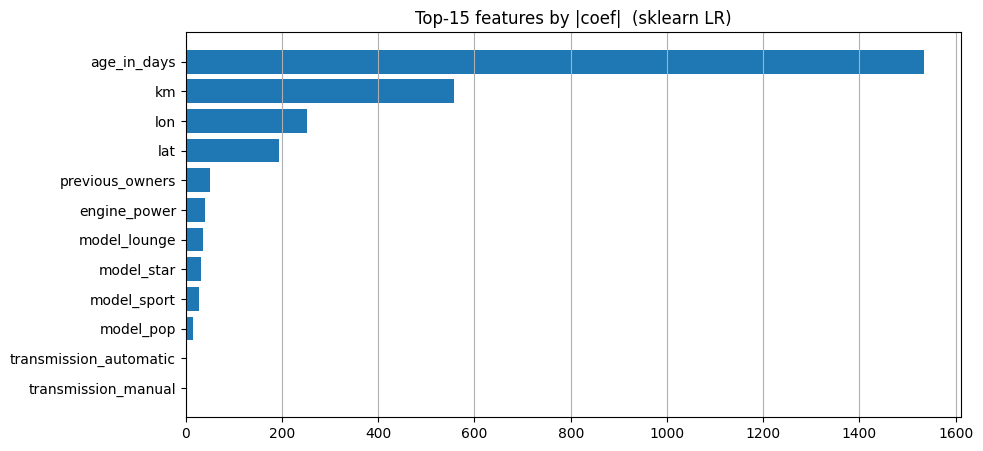

In [11]:
topk = 15
plt.figure(figsize=(10,5))
plt.barh(importance["feature"].head(topk)[::-1], importance["abs_coef"].head(topk)[::-1])
plt.grid(True, axis="x")
plt.title(f"Top-{topk} features by |coef|  ({best_name})")
plt.show()


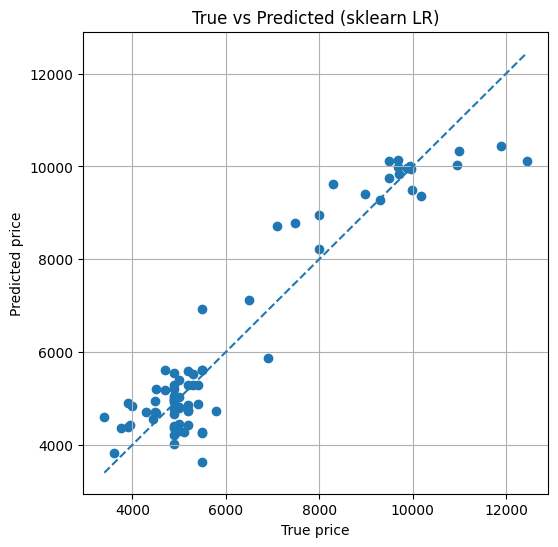

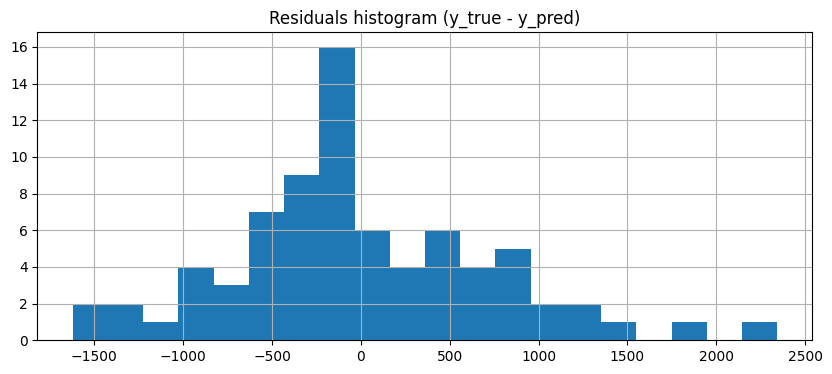

In [12]:
y_pred = best_model.predict(X_test_scaled)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.grid(True)
plt.xlabel("True price")
plt.ylabel("Predicted price")
plt.title(f"True vs Predicted ({best_name})")
plt.show()

resid = y_test - y_pred
plt.figure(figsize=(10,4))
plt.hist(resid, bins=20)
plt.grid(True)
plt.title("Residuals histogram (y_true - y_pred)")
plt.show()


### Вывод

Я обучила несколько вариантов линейной регрессии: собственную реализацию (matrix, gd, sgd) и модели из sklearn (LinearRegression, Ridge, Lasso, ElasticNet). По метрикам на тестовой выборке лучше всего себя показала модель **sklearn LinearRegression** (R2 ≈ 0.895, RMSE ≈ 734), а собственная реализация через **градиентный спуск** дала практически такое же качество. Метод SGD в моих настройках оказался хуже по качеству, вероятно из-за параметров обучения (шаг, число итераций, размер батча).

По важности признаков (по |коэффициенту| после стандартизации) сильнее всего на цену влияют **возраст автомобиля (age_in_days)** и **пробег (km)** — чем они больше, тем цена ниже. Также заметное влияние дают координаты (lat/lon), а модель и тип трансмиссии влияют слабее в сравнении с возрастом и пробегом.


## Задача 2

[Соревнование на Kaggle](https://kaggle.com/competitions/yadro-regression-2025)